In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import cvxpy as cp
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
# ============================================================
# CELL 2 — DOWNLOAD DATA
# ============================================================
EQUITIES = [
    # Technology
    'AAPL',   # Apple
    'MSFT',   # Microsoft
    'NVDA',   # Nvidia

    # Communication & Media
    'GOOGL',  # Alphabet
    'META',   # Meta

    # Consumer Discretionary
    'AMZN',   # Amazon
    'NKE',    # Nike

    # Consumer Staples
    'KO',     # Coca-Cola
    'WMT',    # Walmart

    # Financials
    'JPM',    # JPMorgan
    'GS',     # Goldman Sachs

    # Healthcare
    'JNJ',    # Johnson & Johnson
    'PFE',    # Pfizer

    # Energy
    'XOM',    # ExxonMobil
    'NEE',    # NextEra Energy (renewables)

    # Industrials
    'BA',     # Boeing
    'CAT',    # Caterpillar

    # Materials
    'FCX',    # Freeport-McMoRan (copper/gold mining)

    # Real Estate
    'PLD',    # Prologis (industrial REITs)

    # Utilities
    'DUK',    # Duke Energy
]

# yfinance forex tickers — returns price of 1 unit of base currency in USD
# USDJPY=X and USDCAD=X are USD per JPY/CAD (inverted), but we treat
# all of them uniformly: just compute daily pct_change on the price
FOREX = [
    'EURUSD=X',   # EUR/USD
    'GBPUSD=X',   # GBP/USD
    'USDJPY=X',   # USD/JPY
    'AUDUSD=X',   # AUD/USD
    'USDCAD=X',   # USD/CAD
]

TICKERS = EQUITIES + FOREX

print("Downloading price data...")
raw = yf.download(TICKERS, start='2018-01-01', end='2025-12-31',
                  auto_adjust=True, progress=False)['Close']

# Drop columns with too many NaNs (>5% missing)
raw = raw.dropna(axis=1, thresh=int(0.95 * len(raw)))

# Forward-fill remaining small gaps (e.g. forex on equity holidays)
raw = raw.ffill().dropna()

print(f"Price matrix shape : {raw.shape}")
print(f"Date range         : {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Assets kept        : {raw.columns.tolist()}")


Price matrix shape : (2083, 25)
Date range         : 2018-01-02 to 2025-12-30
Assets kept        : ['AAPL', 'AMZN', 'AUDUSD=X', 'BA', 'CAT', 'DUK', 'EURUSD=X', 'FCX', 'GBPUSD=X', 'GOOGL', 'GS', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NEE', 'NKE', 'NVDA', 'PFE', 'PLD', 'USDCAD=X', 'USDJPY=X', 'WMT', 'XOM']


In [3]:
# ============================================================
# CELL 3 — COMPUTE RETURNS AND TRAIN/TEST SPLIT
# ============================================================
# Simple discrete returns: r_t = (P_t - P_{t-1}) / P_{t-1}
# NOT log returns — required for cross-sectional additivity:
#   portfolio_return_t = R[t, :] @ w
returns = raw.pct_change().dropna()

TRAIN_END = '2023-12-31'
TEST_START = '2024-01-01'

R_train = returns.loc[:TRAIN_END].values          # shape (T_train, N)
R_test  = returns.loc[TEST_START:].values         # shape (T_test,  N)

T_train, N = R_train.shape
T_test      = R_test.shape[0]

mu_train    = R_train.mean(axis=0)                # sample mean (N,)
asset_names = list(returns.columns)

dates_train = returns.loc[:TRAIN_END].index
dates_test  = returns.loc[TEST_START:].index

print(f"\nTraining period : {dates_train[0].date()} to {dates_train[-1].date()}  ({T_train} days)")
print(f"Testing period  : {dates_test[0].date()}  to {dates_test[-1].date()}   ({T_test} days)")
print(f"N assets        : {N}")



Training period : 2018-01-03 to 2023-12-29  (1563 days)
Testing period  : 2024-01-01  to 2025-12-30   (519 days)
N assets        : 25


In [4]:
# ============================================================
# CELL 4 — HELPER FUNCTIONS
# ============================================================
def drawdown_series(weights, R):
    """
    Uncompounded cumulative return and drawdown trajectory.

    xi[t]  = sum_{k=1}^{t} R[k,:] @ w    cumulative return (T+1,)
    dd[t]  = max_{s<=t} xi[s] - xi[t]    drawdown at t    (T+1,)

    Both vectors start at 0 (index 0 = before any trading).
    """
    port_ret    = R @ weights
    cum         = np.concatenate([[0.0], np.cumsum(port_ret)])
    running_max = np.maximum.accumulate(cum)
    dd          = running_max - cum
    return dd, cum


def compute_cdar(dd, alpha=0.95):
    """
    CDaR(alpha) = average of the worst (1-alpha) fraction of drawdowns.
    Skips dd[0]=0 (trivial starting value).
    """
    d         = dd[1:]
    threshold = np.quantile(d, alpha)
    return float(np.mean(d[d >= threshold]))

In [5]:
# ============================================================
# CELL 5 — LP: MINIMISE CDaR  (in-sample, training data)
# ============================================================
#
# min   zeta + 1/((1-alpha)*T) * sum(u)
#
# s.t.  u[t]   >= d[t+1] - zeta        tail-loss slack
#       u[t]   >= 0
#       d[t+1] >= d[t] - (R @ w)[t]    drawdown dynamics
#       d[t+1] >= 0
#       d[0]   = 0
#       sum(w) = 1,  w >= 0
# ============================================================
alpha = 0.95
T     = T_train

w    = cp.Variable(N)
zeta = cp.Variable(1)
u    = cp.Variable(T)
d    = cp.Variable(T + 1)

objective   = cp.Minimize(zeta + (1.0 / ((1 - alpha) * T)) * cp.sum(u))
constraints = [
    u    >= d[1:] - zeta,
    u    >= 0,
    d[1:] >= d[:-1] - R_train @ w,
    d[1:] >= 0,
    d[0]  == 0,
    cp.sum(w) == 1,
    w >= 0,
]

prob_min = cp.Problem(objective, constraints)
prob_min.solve(solver=cp.CLARABEL, verbose=False)

w_min           = w.value
dd_min_train, cum_min_train = drawdown_series(w_min, R_train)
dd_min_test,  cum_min_test  = drawdown_series(w_min, R_test)

print(f"Solver status   : {prob_min.status}")
print(f"CDaR train      : {compute_cdar(dd_min_train):.4%}")
print(f"CDaR test       : {compute_cdar(dd_min_test):.4%}")
print(f"Ann. Return     : {mu_train @ w_min * 252:.4%}")
print(f"\nWeights (CDaR-Min):")
for name, wi in sorted(zip(asset_names, w_min), key=lambda x: -x[1]):
    if wi > 0.001:
        print(f"  {name:<12}  {wi:.1%}")

Solver status   : optimal
CDaR train      : 1.3186%
CDaR test       : 1.2389%
Ann. Return     : 2.2583%

Weights (CDaR-Min):
  USDCAD=X      40.4%
  EURUSD=X      28.2%
  USDJPY=X      18.2%
  KO            3.5%
  AUDUSD=X      3.0%
  PLD           1.7%
  WMT           1.4%
  XOM           1.4%
  MSFT          0.9%
  NEE           0.8%
  NKE           0.3%
  META          0.2%


In [6]:
# ============================================================
# CELL 6 — LP: MAXIMISE RETURN  subject to  CDaR <= 15%
# ============================================================
CDAR_LIMIT = 0.15

w2    = cp.Variable(N)
zeta2 = cp.Variable(1)
u2    = cp.Variable(T)
d2    = cp.Variable(T + 1)

cdar_expr = zeta2 + (1.0 / ((1 - alpha) * T)) * cp.sum(u2)

objective2   = cp.Maximize(mu_train @ w2)
constraints2 = [
    cdar_expr <= CDAR_LIMIT,
    u2    >= d2[1:] - zeta2,
    u2    >= 0,
    d2[1:] >= d2[:-1] - R_train @ w2,
    d2[1:] >= 0,
    d2[0]  == 0,
    cp.sum(w2) == 1,
    w2 >= 0,
]

prob_target = cp.Problem(objective2, constraints2)
prob_target.solve(solver=cp.CLARABEL, verbose=False)

w_target           = w2.value
dd_tgt_train, cum_tgt_train = drawdown_series(w_target, R_train)
dd_tgt_test,  cum_tgt_test  = drawdown_series(w_target, R_test)

print(f"Solver status   : {prob_target.status}")
print(f"CDaR train      : {compute_cdar(dd_tgt_train):.4%}  (limit = {CDAR_LIMIT:.0%})")
print(f"CDaR test       : {compute_cdar(dd_tgt_test):.4%}")
print(f"Ann. Return     : {float(prob_target.value) * 252:.4%}")
print(f"\nWeights (CDaR-Target {CDAR_LIMIT:.0%}):")
for name, wi in sorted(zip(asset_names, w_target), key=lambda x: -x[1]):
    if wi > 0.001:
        print(f"  {name:<12}  {wi:.1%}")

Solver status   : optimal
CDaR train      : 14.9627%  (limit = 15%)
CDaR test       : 14.5921%
Ann. Return     : 23.2434%

Weights (CDaR-Target 15%):
  MSFT          69.7%
  USDJPY=X      15.1%
  XOM           14.4%
  NVDA          0.9%


In [7]:
# ============================================================
# CELL 7 — BENCHMARKS
# ============================================================
w_ew = np.ones(N) / N
dd_ew_train, cum_ew_train = drawdown_series(w_ew, R_train)
dd_ew_test,  cum_ew_test  = drawdown_series(w_ew, R_test)

portfolios = {
    "CDaR-Min"    : (w_min,    dd_min_train, cum_min_train, dd_min_test, cum_min_test),
    "CDaR-15pct"  : (w_target, dd_tgt_train, cum_tgt_train, dd_tgt_test, cum_tgt_test),
    "Equal-Weight": (w_ew,     dd_ew_train,  cum_ew_train,  dd_ew_test,  cum_ew_test),
}
colors = {"CDaR-Min": "#4FC3F7", "CDaR-15pct": "#81C784", "Equal-Weight": "#FFB74D"}
lines  = {"CDaR-Min": "-",       "CDaR-15pct": "-",        "Equal-Weight": "--"}

print(f"\n{'Portfolio':<15} {'Train Ret':>10} {'Train CDaR':>11} "
      f"{'Train MaxDD':>12} {'Test CDaR':>10} {'Test MaxDD':>11}")
print("-" * 72)
for name, (w_, dd_tr, _, dd_te, _) in portfolios.items():
    print(f"{name:<15} {mu_train @ w_ * 252:>9.2%} "
          f"{compute_cdar(dd_tr):>10.2%} {dd_tr.max():>11.2%} "
          f"{compute_cdar(dd_te):>9.2%} {dd_te.max():>10.2%}")


Portfolio        Train Ret  Train CDaR  Train MaxDD  Test CDaR  Test MaxDD
------------------------------------------------------------------------
CDaR-Min            2.26%      1.32%       1.84%     1.24%      1.64%
CDaR-15pct         23.24%     14.96%      28.13%    14.59%     19.91%
Equal-Weight       14.12%     18.84%      32.73%     9.05%     16.73%


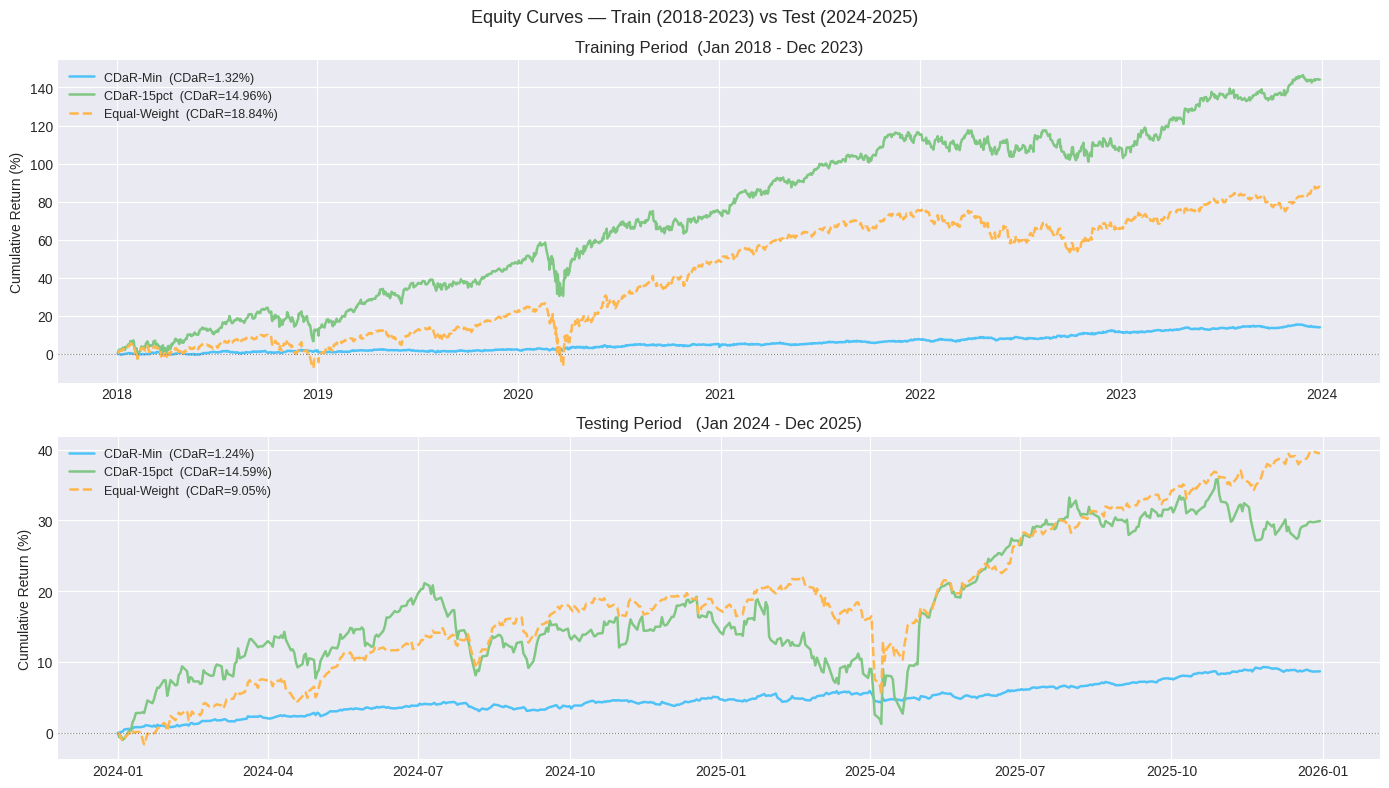

In [8]:
# ============================================================
# CELL 8 — PLOT: TRAIN + TEST EQUITY CURVES
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Equity Curves — Train (2018-2023) vs Test (2024-2025)", fontsize=13)

for ax, (period_dates, cum_key, title) in zip(
    axes,
    [
        (dates_train, 2, "Training Period  (Jan 2018 - Dec 2023)"),
        (dates_test,  4, "Testing Period   (Jan 2024 - Dec 2025)"),
    ]
):
    for name, vals in portfolios.items():
        cum_ = vals[cum_key]
        cdar_ = compute_cdar(vals[cum_key - 1])
        ax.plot(period_dates, cum_[1:] * 100,
                color=colors[name], linestyle=lines[name],
                linewidth=1.8, label=f"{name}  (CDaR={cdar_:.2%})")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_ylabel("Cumulative Return (%)")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

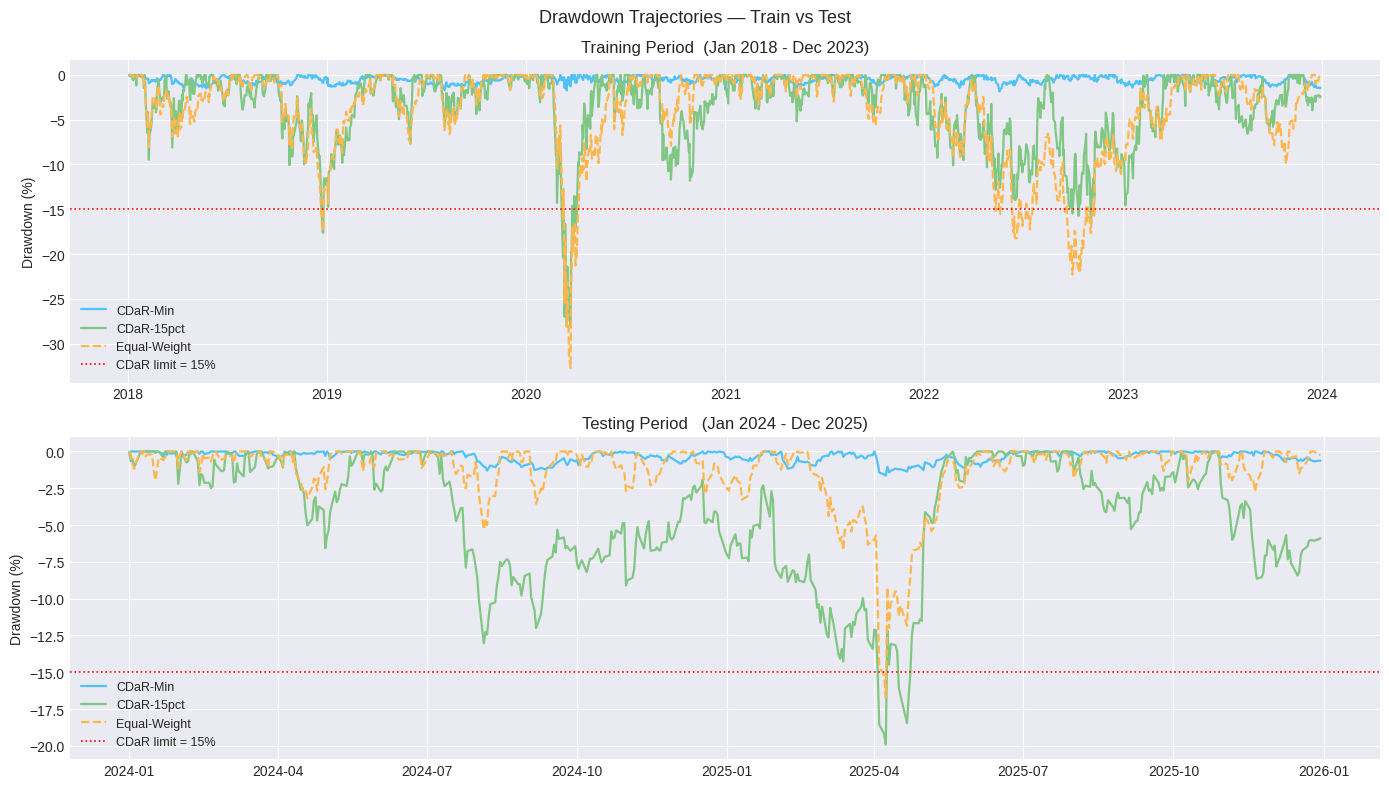

In [9]:
# ============================================================
# CELL 9 — PLOT: DRAWDOWN TRAJECTORIES (TRAIN + TEST)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Drawdown Trajectories — Train vs Test", fontsize=13)

for ax, (period_dates, dd_key, title) in zip(
    axes,
    [
        (dates_train, 1, "Training Period  (Jan 2018 - Dec 2023)"),
        (dates_test,  3, "Testing Period   (Jan 2024 - Dec 2025)"),
    ]
):
    for name, vals in portfolios.items():
        dd_ = vals[dd_key]
        ax.plot(period_dates, -dd_[1:] * 100,
                color=colors[name], linestyle=lines[name],
                linewidth=1.6, label=name)
    ax.axhline(-CDAR_LIMIT * 100, color="red", linewidth=1.2,
               linestyle=":", label=f"CDaR limit = {CDAR_LIMIT:.0%}")
    ax.set_ylabel("Drawdown (%)")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

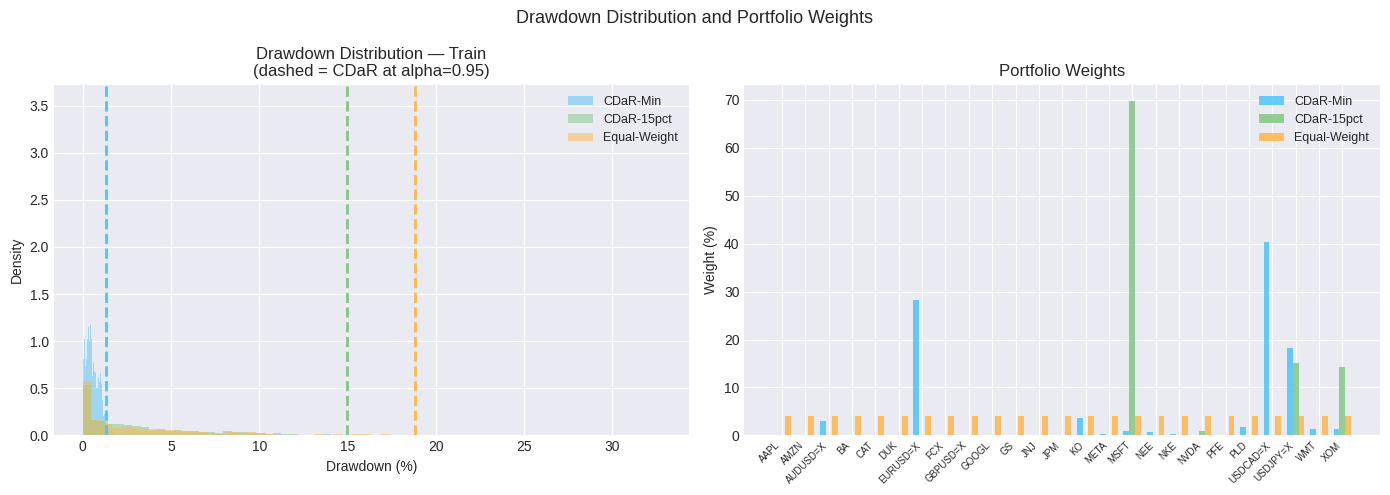

In [10]:
# ============================================================
# CELL 10 — PLOT: DRAWDOWN DISTRIBUTION + WEIGHTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Drawdown Distribution and Portfolio Weights", fontsize=13)

# Panel A: drawdown histogram (training)
ax1 = axes[0]
for name, (_, dd_tr, _, _, _) in portfolios.items():
    cdar_ = compute_cdar(dd_tr)
    ax1.hist(dd_tr[1:] * 100, bins=60, color=colors[name],
             alpha=0.5, density=True, label=name, edgecolor="none")
    ax1.axvline(cdar_ * 100, color=colors[name], linewidth=2,
                linestyle="--")
ax1.set_xlabel("Drawdown (%)")
ax1.set_ylabel("Density")
ax1.set_title("Drawdown Distribution — Train\n(dashed = CDaR at alpha=0.95)")
ax1.legend(fontsize=9)

# Panel B: weight bar chart — top holdings only (weight > 1%)
ax2 = axes[1]
x    = np.arange(N)
w_   = 0.25
for i, (name, (wts, *_)) in enumerate(portfolios.items()):
    ax2.bar(x + (i - 1) * w_, wts * 100, w_,
            label=name, color=colors[name], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(asset_names, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Weight (%)")
ax2.set_title("Portfolio Weights")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

Sweeping CDaR limits for efficient frontier...


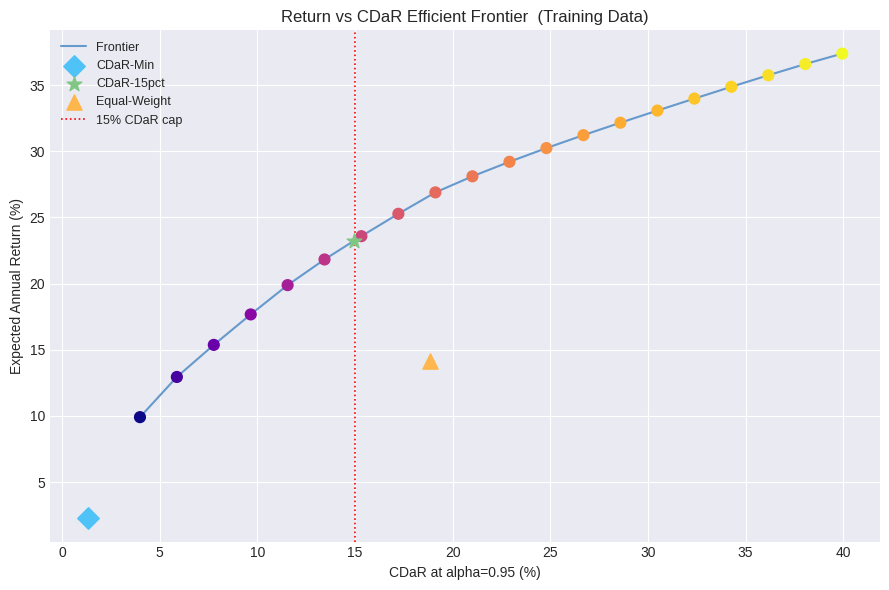

In [11]:
# ============================================================
# CELL 11 — PLOT: RETURN-CDaR EFFICIENT FRONTIER (in-sample)
# ============================================================
print("Sweeping CDaR limits for efficient frontier...")

cdar_limits   = np.linspace(0.04, 0.40, 20)
frontier_ret  = []
frontier_cdar = []

for lim in cdar_limits:
    wf    = cp.Variable(N)
    zetaf = cp.Variable(1)
    uf    = cp.Variable(T)
    df    = cp.Variable(T + 1)

    cdar_f = zetaf + (1.0 / ((1 - alpha) * T)) * cp.sum(uf)
    cons_f = [
        cdar_f <= lim,
        uf >= df[1:] - zetaf, uf >= 0,
        df[1:] >= df[:-1] - R_train @ wf,
        df[1:] >= 0, df[0] == 0,
        cp.sum(wf) == 1, wf >= 0,
    ]
    prob_f = cp.Problem(cp.Maximize(mu_train @ wf), cons_f)
    prob_f.solve(solver=cp.CLARABEL, verbose=False)

    if prob_f.status in ("optimal", "optimal_inaccurate") and wf.value is not None:
        dd_f, _ = drawdown_series(wf.value, R_train)
        frontier_ret.append(float(prob_f.value) * 252)
        frontier_cdar.append(compute_cdar(dd_f))

frontier_ret  = np.array(frontier_ret)
frontier_cdar = np.array(frontier_cdar)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(frontier_cdar * 100, frontier_ret * 100,
        color="#6699cc", linewidth=1.5, label="Frontier")
ax.scatter(frontier_cdar * 100, frontier_ret * 100,
           c=frontier_ret * 100, cmap="plasma", s=60, zorder=4)

# Overlay the three portfolios
for name, (wts, dd_tr, _, _, _) in portfolios.items():
    ax.scatter(compute_cdar(dd_tr) * 100, mu_train @ wts * 252 * 100,
               color=colors[name], s=120, zorder=5,
               marker="*" if "15pct" in name else "^" if "Equal" in name else "D",
               label=name)

ax.axvline(CDAR_LIMIT * 100, color="red", linewidth=1.2,
           linestyle=":", label=f"15% CDaR cap")
ax.set_xlabel("CDaR at alpha=0.95 (%)")
ax.set_ylabel("Expected Annual Return (%)")
ax.set_title("Return vs CDaR Efficient Frontier  (Training Data)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()